In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/cleaned_superstore.csv")

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed"
)

print(df.shape)

(9994, 28)


In [3]:
features = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Days",
    "Average Selling Price",
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode"
]

X = df[features]
y = df["Profit"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7995
Testing samples: 1999


In [5]:
categorical_features = [
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode"
]

numerical_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Days",
    "Average Selling Price"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [6]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [7]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [8]:
pipeline.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [11]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

MAE: 25.89
RMSE: 226.58
R² Score: -0.0589


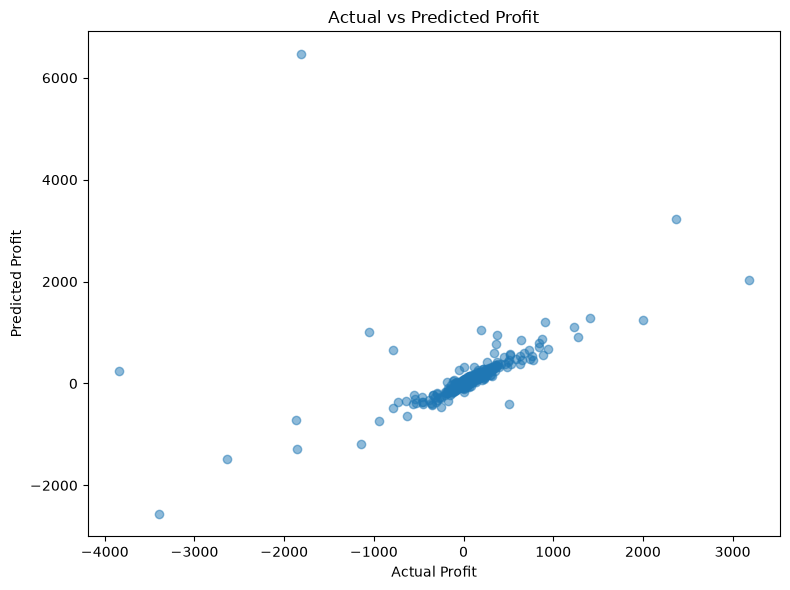

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.tight_layout()
plt.show()

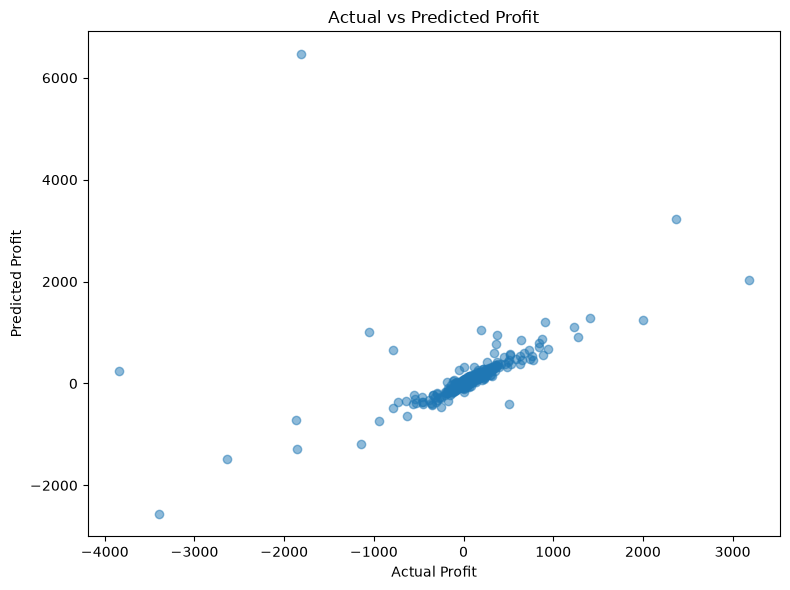

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.tight_layout()
plt.show()

In [15]:
import joblib

joblib.dump(
    pipeline,
    "../models/profit_prediction_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
